# In this notebook, we present the code used to train the model on the MNIST dataset

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from spectraltools import Spectral
from tensorflow import keras
from tensorflow.keras.datasets import mnist

The MNIST dataset is imported and normalized.

In [2]:
#MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = np.reshape(x_train, [-1, 784])
x_test = np.reshape(x_test, [-1, 784])


Remove this part if you want to train on the whole MNIST dataset. Cange the selected digits if you want to train the model on another couple of digits.

In [3]:
x_train = x_train[np.logical_or(y_train == 0, y_train == 1)]
y_train = y_train[np.logical_or(y_train == 0, y_train == 1)]
x_test = x_test[np.logical_or(y_test == 0, y_test == 1)]
y_test = y_test[np.logical_or(y_test == 0, y_test == 1)]

The Sequential class in tf.keras is used to build the model layer-by-layer. A Spectral layer is used as first layer.

In [4]:

def spectral_model():
    mod = tf.keras.Sequential()
    mod.add(tf.keras.Input(shape=(x_train.shape[1])))
    mod.add(Spectral(units=100,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones',
                     diag_regularizer=tf.keras.regularizers.L2(l2=1e-2),
                     base_regularizer=tf.keras.regularizers.L2(l2=1e-4)))
    mod.add(tf.keras.layers.BatchNormalization())
#    mod.add(tf.keras.layers.Dropout(0.2))
    mod.add(Spectral(units=100,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    mod.add(Spectral(10,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='linear',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    return mod

The model is trained and the input eigenvalues are stored.

In [5]:
mod = spectral_model()

mod.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), #'mse',#
    metrics='accuracy',
)
hist = mod.fit(x_train, y_train,
               batch_size=500,
               epochs=5000,
               validation_split=0.1,
               verbose=1)

'spectral eigenvalues of input layer'
eig_start = Spectral.return_diag(mod.layers[0])
base_start = mod.layers[0].base
norma = tf.linalg.norm(base_start, ord=2, axis=1)
eig_norm = (eig_start*norma).numpy()

Epoch 1/5000
23/23 [==============================] - 3s 24ms/step - loss: 9.6573 - accuracy: 0.4315 - val_loss: 9.5255 - val_accuracy: 0.9313
Epoch 2/5000
23/23 [==============================] - 0s 13ms/step - loss: 8.6476 - accuracy: 0.9250 - val_loss: 9.1171 - val_accuracy: 0.9961
Epoch 3/5000
23/23 [==============================] - 0s 10ms/step - loss: 8.1360 - accuracy: 0.9872 - val_loss: 8.7461 - val_accuracy: 0.9984
Epoch 4/5000
23/23 [==============================] - 0s 13ms/step - loss: 7.9128 - accuracy: 0.9953 - val_loss: 8.4419 - val_accuracy: 0.9992
Epoch 5/5000
23/23 [==============================] - 0s 15ms/step - loss: 7.8019 - accuracy: 0.9970 - val_loss: 8.2048 - val_accuracy: 1.0000
Epoch 6/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.7310 - accuracy: 0.9975 - val_loss: 8.0171 - val_accuracy: 1.0000
Epoch 7/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.6758 - accuracy: 0.9979 - val_loss: 7.8695 - val_accuracy: 1.0000

Epoch 58/5000
23/23 [==============================] - 0s 18ms/step - loss: 5.9677 - accuracy: 0.9999 - val_loss: 5.9515 - val_accuracy: 1.0000
Epoch 59/5000
23/23 [==============================] - 0s 17ms/step - loss: 5.9378 - accuracy: 0.9999 - val_loss: 5.9218 - val_accuracy: 1.0000
Epoch 60/5000
23/23 [==============================] - 0s 18ms/step - loss: 5.9082 - accuracy: 0.9999 - val_loss: 5.8923 - val_accuracy: 1.0000
Epoch 61/5000
23/23 [==============================] - 0s 18ms/step - loss: 5.8786 - accuracy: 0.9999 - val_loss: 5.8628 - val_accuracy: 1.0000
Epoch 62/5000
23/23 [==============================] - 0s 17ms/step - loss: 5.8492 - accuracy: 0.9999 - val_loss: 5.8334 - val_accuracy: 1.0000
Epoch 63/5000
23/23 [==============================] - 0s 18ms/step - loss: 5.8198 - accuracy: 0.9999 - val_loss: 5.8041 - val_accuracy: 1.0000
Epoch 64/5000
23/23 [==============================] - 0s 17ms/step - loss: 5.7905 - accuracy: 0.9999 - val_loss: 5.7749 - val_accuracy:

Epoch 115/5000
23/23 [==============================] - 0s 17ms/step - loss: 4.4208 - accuracy: 1.0000 - val_loss: 4.4078 - val_accuracy: 1.0000
Epoch 116/5000
23/23 [==============================] - 0s 18ms/step - loss: 4.3962 - accuracy: 1.0000 - val_loss: 4.3833 - val_accuracy: 1.0000
Epoch 117/5000
23/23 [==============================] - 0s 18ms/step - loss: 4.3717 - accuracy: 1.0000 - val_loss: 4.3588 - val_accuracy: 1.0000
Epoch 118/5000
23/23 [==============================] - 0s 18ms/step - loss: 4.3473 - accuracy: 1.0000 - val_loss: 4.3345 - val_accuracy: 1.0000
Epoch 119/5000
23/23 [==============================] - 0s 18ms/step - loss: 4.3230 - accuracy: 1.0000 - val_loss: 4.3102 - val_accuracy: 1.0000
Epoch 120/5000
23/23 [==============================] - 0s 18ms/step - loss: 4.2987 - accuracy: 1.0000 - val_loss: 4.2860 - val_accuracy: 1.0000
Epoch 121/5000
23/23 [==============================] - 0s 17ms/step - loss: 4.2746 - accuracy: 1.0000 - val_loss: 4.2618 - val_ac

23/23 [==============================] - 0s 19ms/step - loss: 3.1677 - accuracy: 1.0000 - val_loss: 3.1571 - val_accuracy: 1.0000
Epoch 172/5000
23/23 [==============================] - 0s 19ms/step - loss: 3.1475 - accuracy: 1.0000 - val_loss: 3.1370 - val_accuracy: 1.0000
Epoch 173/5000
23/23 [==============================] - 0s 18ms/step - loss: 3.1275 - accuracy: 1.0000 - val_loss: 3.1169 - val_accuracy: 1.0000
Epoch 174/5000
23/23 [==============================] - 0s 19ms/step - loss: 3.1074 - accuracy: 1.0000 - val_loss: 3.0969 - val_accuracy: 1.0000
Epoch 175/5000
23/23 [==============================] - 0s 17ms/step - loss: 3.0875 - accuracy: 1.0000 - val_loss: 3.0770 - val_accuracy: 1.0000
Epoch 176/5000
23/23 [==============================] - 0s 18ms/step - loss: 3.0676 - accuracy: 1.0000 - val_loss: 3.0572 - val_accuracy: 1.0000
Epoch 177/5000
23/23 [==============================] - 0s 18ms/step - loss: 3.0478 - accuracy: 1.0000 - val_loss: 3.0374 - val_accuracy: 1.0000


23/23 [==============================] - 0s 16ms/step - loss: 2.1511 - accuracy: 1.0000 - val_loss: 2.1426 - val_accuracy: 1.0000
Epoch 228/5000
23/23 [==============================] - 0s 13ms/step - loss: 2.1350 - accuracy: 1.0000 - val_loss: 2.1265 - val_accuracy: 1.0000
Epoch 229/5000
23/23 [==============================] - 0s 15ms/step - loss: 2.1189 - accuracy: 1.0000 - val_loss: 2.1105 - val_accuracy: 1.0000
Epoch 230/5000
23/23 [==============================] - 0s 15ms/step - loss: 2.1030 - accuracy: 1.0000 - val_loss: 2.0946 - val_accuracy: 1.0000
Epoch 231/5000
23/23 [==============================] - 1s 26ms/step - loss: 2.0871 - accuracy: 1.0000 - val_loss: 2.0787 - val_accuracy: 1.0000
Epoch 232/5000
23/23 [==============================] - 1s 38ms/step - loss: 2.0712 - accuracy: 1.0000 - val_loss: 2.0629 - val_accuracy: 1.0000
Epoch 233/5000
23/23 [==============================] - 1s 37ms/step - loss: 2.0555 - accuracy: 1.0000 - val_loss: 2.0472 - val_accuracy: 1.0000


...

23/23 [==============================] - 0s 18ms/step - loss: 8.6196e-05 - accuracy: 1.0000 - val_loss: 8.9261e-05 - val_accuracy: 1.0000
Epoch 4756/5000
23/23 [==============================] - 0s 19ms/step - loss: 8.6956e-05 - accuracy: 1.0000 - val_loss: 8.7406e-05 - val_accuracy: 1.0000
Epoch 4757/5000
23/23 [==============================] - 0s 18ms/step - loss: 8.4821e-05 - accuracy: 1.0000 - val_loss: 8.6578e-05 - val_accuracy: 1.0000
Epoch 4758/5000
23/23 [==============================] - 0s 19ms/step - loss: 8.5717e-05 - accuracy: 1.0000 - val_loss: 8.5864e-05 - val_accuracy: 1.0000
Epoch 4759/5000
23/23 [==============================] - 0s 18ms/step - loss: 8.3662e-05 - accuracy: 1.0000 - val_loss: 8.5259e-05 - val_accuracy: 1.0000
Epoch 4760/5000
23/23 [==============================] - 0s 19ms/step - loss: 8.3497e-05 - accuracy: 1.0000 - val_loss: 8.4571e-05 - val_accuracy: 1.0000
Epoch 4761/5000
23/23 [==============================] - 0s 18ms/step - loss: 8.5164e-05 - a

23/23 [==============================] - 0s 19ms/step - loss: 6.7543e-05 - accuracy: 1.0000 - val_loss: 6.7509e-05 - val_accuracy: 1.0000
Epoch 4809/5000
23/23 [==============================] - 0s 19ms/step - loss: 6.7462e-05 - accuracy: 1.0000 - val_loss: 6.7271e-05 - val_accuracy: 1.0000
Epoch 4810/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.1966e-05 - accuracy: 1.0000 - val_loss: 6.6825e-05 - val_accuracy: 1.0000
Epoch 4811/5000
23/23 [==============================] - 0s 18ms/step - loss: 6.6603e-05 - accuracy: 1.0000 - val_loss: 6.6449e-05 - val_accuracy: 1.0000
Epoch 4812/5000
23/23 [==============================] - 0s 19ms/step - loss: 6.7904e-05 - accuracy: 1.0000 - val_loss: 6.6247e-05 - val_accuracy: 1.0000
Epoch 4813/5000
23/23 [==============================] - 0s 18ms/step - loss: 6.6157e-05 - accuracy: 1.0000 - val_loss: 6.6016e-05 - val_accuracy: 1.0000
Epoch 4814/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.8209e-05 - a

23/23 [==============================] - 0s 18ms/step - loss: 7.2898e-05 - accuracy: 1.0000 - val_loss: 7.1113e-05 - val_accuracy: 1.0000
Epoch 4862/5000
23/23 [==============================] - 0s 19ms/step - loss: 1.2367e-04 - accuracy: 1.0000 - val_loss: 7.2667e-05 - val_accuracy: 1.0000
Epoch 4863/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.0189e-05 - accuracy: 1.0000 - val_loss: 7.8978e-05 - val_accuracy: 1.0000
Epoch 4864/5000
23/23 [==============================] - 0s 19ms/step - loss: 7.0319e-05 - accuracy: 1.0000 - val_loss: 7.4506e-05 - val_accuracy: 1.0000
Epoch 4865/5000
23/23 [==============================] - 0s 18ms/step - loss: 7.4173e-05 - accuracy: 1.0000 - val_loss: 7.0389e-05 - val_accuracy: 1.0000
Epoch 4866/5000
23/23 [==============================] - 0s 16ms/step - loss: 7.3407e-05 - accuracy: 1.0000 - val_loss: 6.9486e-05 - val_accuracy: 1.0000
Epoch 4867/5000
23/23 [==============================] - 0s 14ms/step - loss: 6.9717e-05 - a

23/23 [==============================] - 0s 18ms/step - loss: 6.0083e-05 - accuracy: 1.0000 - val_loss: 5.8638e-05 - val_accuracy: 1.0000
Epoch 4915/5000
23/23 [==============================] - 0s 19ms/step - loss: 5.8334e-05 - accuracy: 1.0000 - val_loss: 5.8418e-05 - val_accuracy: 1.0000
Epoch 4916/5000
23/23 [==============================] - 0s 19ms/step - loss: 5.8915e-05 - accuracy: 1.0000 - val_loss: 5.8182e-05 - val_accuracy: 1.0000
Epoch 4917/5000
23/23 [==============================] - 0s 18ms/step - loss: 5.7897e-05 - accuracy: 1.0000 - val_loss: 5.7938e-05 - val_accuracy: 1.0000
Epoch 4918/5000
23/23 [==============================] - 0s 17ms/step - loss: 5.7929e-05 - accuracy: 1.0000 - val_loss: 5.7699e-05 - val_accuracy: 1.0000
Epoch 4919/5000
23/23 [==============================] - 0s 19ms/step - loss: 5.7385e-05 - accuracy: 1.0000 - val_loss: 5.7471e-05 - val_accuracy: 1.0000
Epoch 4920/5000
23/23 [==============================] - 0s 15ms/step - loss: 5.7361e-05 - a

23/23 [==============================] - 0s 18ms/step - loss: 1.6842e-04 - accuracy: 0.9999 - val_loss: 9.5354e-05 - val_accuracy: 1.0000
Epoch 4968/5000
23/23 [==============================] - 0s 17ms/step - loss: 1.3216e-04 - accuracy: 1.0000 - val_loss: 9.5301e-05 - val_accuracy: 1.0000
Epoch 4969/5000
23/23 [==============================] - 0s 17ms/step - loss: 9.1403e-05 - accuracy: 1.0000 - val_loss: 9.3064e-05 - val_accuracy: 1.0000
Epoch 4970/5000
23/23 [==============================] - 0s 18ms/step - loss: 9.1059e-05 - accuracy: 1.0000 - val_loss: 9.1096e-05 - val_accuracy: 1.0000
Epoch 4971/5000
23/23 [==============================] - 0s 17ms/step - loss: 9.1656e-05 - accuracy: 1.0000 - val_loss: 9.0107e-05 - val_accuracy: 1.0000
Epoch 4972/5000
23/23 [==============================] - 0s 18ms/step - loss: 8.9725e-05 - accuracy: 1.0000 - val_loss: 8.9485e-05 - val_accuracy: 1.0000
Epoch 4973/5000
23/23 [==============================] - 0s 17ms/step - loss: 8.9274e-05 - a

We compute the model's accuracy as an increasing number of pixels is used as input. The pixels are added in order of the absolute magnitude of their corresponding eigenvalues.

In [6]:
acc_prune = []

for n in range(1,100):
    mask = eig_norm.reshape((28,28)).copy()
    th = np.sort(np.abs(eig_norm))[-n]
    mask[np.abs(mask)<th]=0
    mask[np.abs(mask)>=th]=1
    acc_prune.append(mod.evaluate(x_test*mask.reshape(784,), y_test, verbose=0)[1])

The rusults are plotted

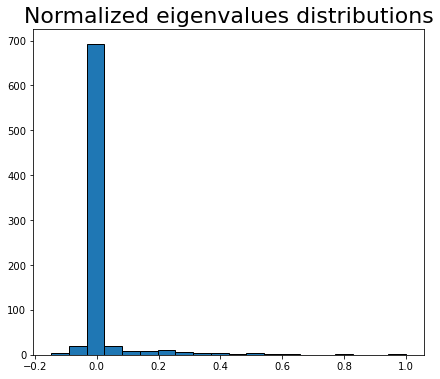

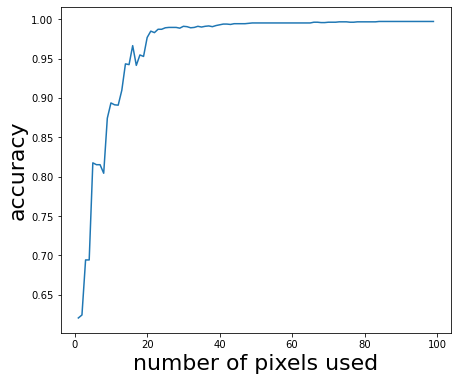

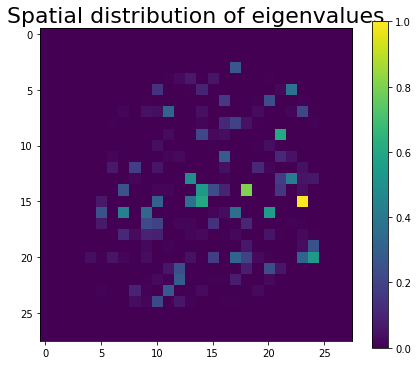

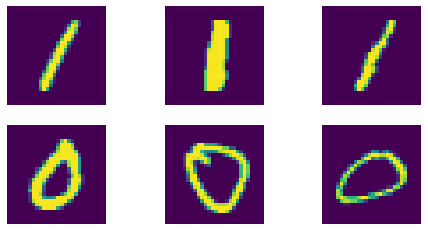

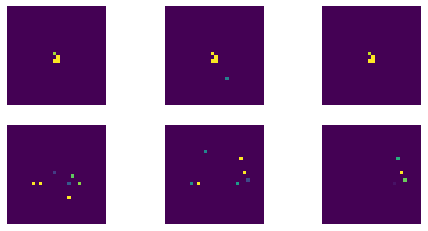

In [8]:
fnt_size = 22

plt.figure(figsize=(7,6))
plt.title('Normalized eigenvalues distributions', fontsize=fnt_size)
plt.hist(eig_norm/eig_norm.max(), 20, edgecolor='k', density=False)
plt.show()


plt.figure(figsize=(7,6))
plt.plot(np.arange(1, 100), acc_prune)
plt.xlabel('number of pixels used', fontsize=fnt_size)
plt.ylabel('accuracy', fontsize=fnt_size)
plt.show()


plt.figure(figsize=(7,6))
plt.imshow(np.abs(eig_norm.reshape((28, 28)))/eig_norm.max())
plt.colorbar()
plt.title('Spatial distribution of eigenvalues', fontsize=fnt_size)
plt.show()


# we plot some examples from the test test by showing only the most relevant pixels according to our method

mask = eig_norm.reshape((28,28)).copy()
th = np.sort(np.abs(eig_norm))[-17] 
mask[np.abs(mask)<th]=0
mask[np.abs(mask)>=th]=1

random_examples = list(np.random.randint(0,2000,6))
i = 0
fig, ax = plt.subplots(2,3,figsize=(8,4))
for n in random_examples:
    ax[int(np.floor(i/3)),np.mod(i,3)].imshow(x_test[n].reshape(28,28))
    ax[int(np.floor(i/3)),np.mod(i,3)].axis('off')
    i +=1
plt.show()
i = 0
fig, ax = plt.subplots(2,3,figsize=(8,4))
for n in random_examples:
    ax[int(np.floor(i/3)),np.mod(i,3)].imshow(np.multiply(x_test[n].reshape(28,28),mask))
    ax[int(np.floor(i/3)),np.mod(i,3)].axis('off')
    i +=1
plt.show()